<a href="https://colab.research.google.com/github/keyonai/License-Plate-Recognition/blob/main/License_Plate_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
!apt install -y tesseract-ocr #Instaalling Tesseract ocr
!pip install pytesseract opencv-python
#using tesseract and opencv
import cv2
import pytesseract
import matplotlib.pyplot as plt
import os # Added for temporary file handling

#function to detect license plate number
def detect_plate_number(image_path):
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Could not read image from {image_path}. Please check the path and file integrity.")
        return None
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
# edge detection
    edges = cv2.Canny(blurred, 100, 200)
    contours, _ = cv2.findContours(edges.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#Approximate Contours and Check for a Rectangle
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    plate_contour = None
    for contour in contours:
        epsilon = 0.02 * cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, epsilon, True)

        if len(approx) == 4:
            plate_contour = approx
            break
# extract license plate and apply Thresholding
    if plate_contour is not None:

        x, y, w, h = cv2.boundingRect(plate_contour)
        plate_image = gray[y:y + h, x:x + w]

        _, thresh = cv2.threshold(plate_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# ocr
        plate_number = pytesseract.image_to_string(thresh, config='--psm 8')  # Treat it as a single word
        return plate_number.strip()
    else:
        print("No rectangular contour found, unable to detect license plate.")
        return None

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [12]:
!pip install easyocr

In [13]:
import easyocr

def detect_plate_number_easyocr(image_path):
    try:
        # Initialize EasyOCR reader (this downloads models on first run)
        reader = easyocr.Reader(['en'], gpu=False) # 'en' for English, set gpu=True if you have a GPU

        # Read the image
        image = cv2.imread(image_path)
        if image is None:
            print(f"Error: Could not read image from {image_path}. Please check the path and file integrity.")
            return None

        # Display the image
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title('Image for EasyOCR processing')
        plt.show()

        # Perform OCR
        results = reader.readtext(image)

        detected_texts = []
        for (bbox, text, prob) in results:
            # Filter for text that looks like a license plate (e.g., alphanumeric, certain length)
            # This is a basic filter; more advanced logic might be needed for better accuracy
            clean_text = ''.join(filter(str.isalnum, text)).upper()
            if len(clean_text) > 2: # Simple length filter
                detected_texts.append(clean_text)

        if detected_texts:
            # Return the first detected text as the plate number for simplicity
            # In a real scenario, you might want more sophisticated logic to choose the best one
            return detected_texts[0]
        else:
            print("No text detected by EasyOCR or filtered out.")
            return None

    except Exception as e:
        print(f"An error occurred during EasyOCR detection: {e}")
        return None

Saving blue-pickup-truck-motion-power-reliability-road.jpg to blue-pickup-truck-motion-power-reliability-road (2).jpg
Uploaded file: blue-pickup-truck-motion-power-reliability-road (2).jpg saved to /tmp/blue-pickup-truck-motion-power-reliability-road (2).jpg


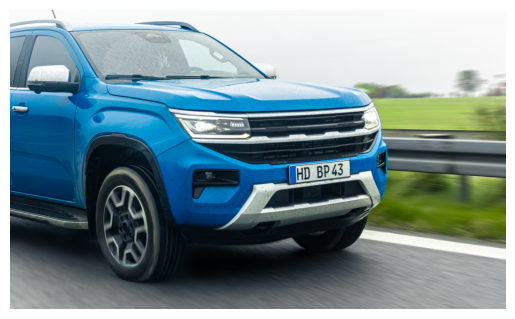

Detected Plate Number: HD BP43_
Removed temporary file: /tmp/blue-pickup-truck-motion-power-reliability-road (2).jpg


In [14]:
from google.colab import files
import shutil
import os

uploaded = files.upload()

image_path = None
if uploaded:
    for filename, content in uploaded.items():
        image_path = os.path.join("/tmp", filename)
        with open(image_path, "wb") as f:
            f.write(content)
        print(f"Uploaded file: {filename} saved to {image_path}")
        break # Assuming only one file upload for simplicity

    if image_path:
        plate_number = detect_plate_number(image_path)
        if plate_number:
            print("Detected Plate Number:", plate_number)
        else:
            print("License plate detection failed.")
        # Clean up the temporary file
        os.remove(image_path)
        print(f"Removed temporary file: {image_path}")
else:
    print("No file uploaded.")


Saving white-crossover-freeway-overpass-road-ahead.jpg to white-crossover-freeway-overpass-road-ahead (1).jpg
Uploaded file: white-crossover-freeway-overpass-road-ahead (1).jpg saved to /tmp/white-crossover-freeway-overpass-road-ahead (1).jpg

Detecting license plate using EasyOCR...


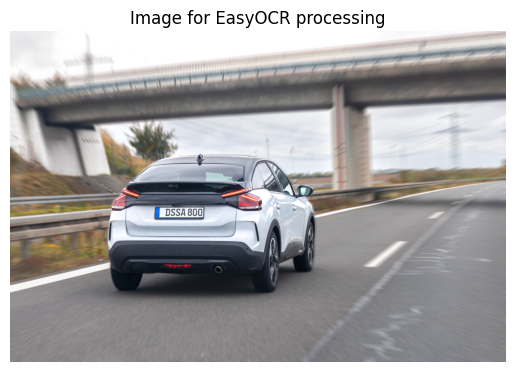

Detected Plate Number (EasyOCR): DSSA800
Removed temporary file: /tmp/white-crossover-freeway-overpass-road-ahead (1).jpg


In [16]:
from google.colab import files
import os

uploaded_easyocr = files.upload()

image_path_easyocr = None
if uploaded_easyocr:
    for filename, content in uploaded_easyocr.items():
        image_path_easyocr = os.path.join("/tmp", filename)
        with open(image_path_easyocr, "wb") as f:
            f.write(content)
        print(f"Uploaded file: {filename} saved to {image_path_easyocr}")
        break # Assuming only one file upload for simplicity

    if image_path_easyocr:
        print("\nDetecting license plate using EasyOCR...")
        plate_number_easyocr = detect_plate_number_easyocr(image_path_easyocr)
        if plate_number_easyocr:
            print("Detected Plate Number (EasyOCR):", plate_number_easyocr)
        else:
            print("License plate detection failed with EasyOCR.")
        # Clean up the temporary file
        os.remove(image_path_easyocr)
        print(f"Removed temporary file: {image_path_easyocr}")
else:
    print("No file uploaded for EasyOCR detection.")